# 🌍 VayuGuard AI/ML Dashboard
## Quantum-Classical Hybrid AQI Forecasting System
**Capstone Project | AI/ML Track**

In [1]:
# Cell 1: Setup & Imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import json
import requests
import os
import sys

sys.path.append('../src')
from utils import load_data, aqi_category

plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("Set2")
print("✅ Dashboard setup complete")

✅ Dashboard setup complete


In [2]:
# Cell 2: Load All Model Metrics
models_data = []
configs = [
    ('Prophet Baseline', 'Baseline', '../models_saved/prophet_Delhi_metrics.json'),
    ('XGBoost Classical', 'Classical ML', '../models_saved/xgboost_24h_metrics.json'),
    ('Quantum Hybrid', 'Quantum-Classical', '../models_saved/simple_quantum_metrics.json')
]

for name, mtype, path in configs:
    if os.path.exists(path):
        with open(path) as f:
            m = json.load(f)
        models_data.append({
            'Model': name, 'Type': mtype, 
            'MAE': round(m.get('mae', m.get('avg_mae', 0)), 2),
            'R²': round(m.get('r2', m.get('avg_r2', 0)), 3)
        })

df_models = pd.DataFrame(models_data)
print(df_models.to_string(index=False) if not df_models.empty else "⚠️ No metrics found.")

            Model              Type   MAE     R²
XGBoost Classical      Classical ML 82.32 -0.754
   Quantum Hybrid Quantum-Classical 12.27  0.886


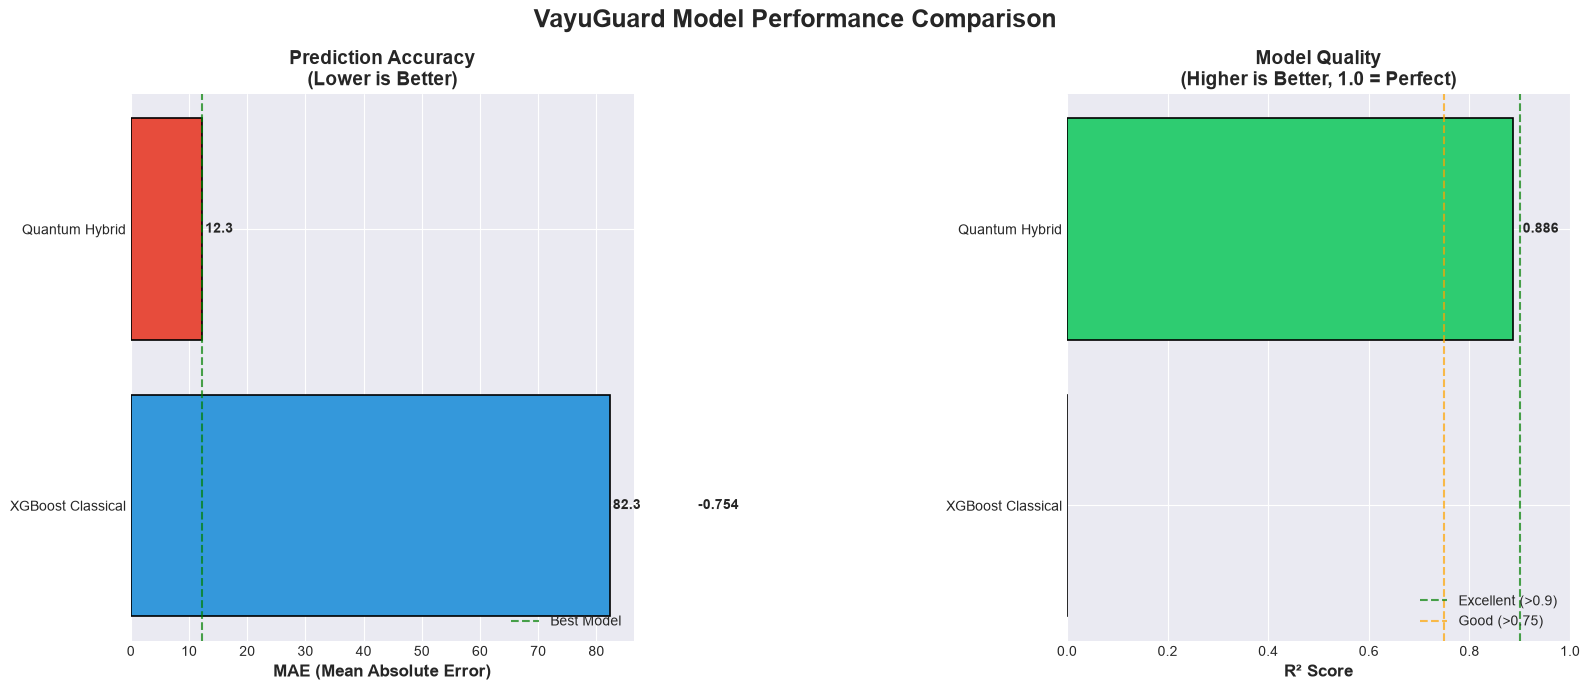

✅ Advanced comparison charts successfully generated and saved!


In [5]:
# Cell 3: Advanced Model Comparison Charts
if not df_models.empty:
    fig, axes = plt.subplots(1, 2, figsize=(16, 7))
    fig.suptitle('VayuGuard Model Performance Comparison', fontsize=18, fontweight='bold', y=0.98)
    
    # Chart 1: MAE Comparison (Lower is Better)
    colors1 = ['#e74c3c' if 'Quantum' in m else '#3498db' for m in df_models['Model']]
    bars1 = axes[0].barh(df_models['Model'], df_models['MAE'], color=colors1, edgecolor='black', linewidth=1.2)
    axes[0].set_xlabel('MAE (Mean Absolute Error)', fontsize=12, fontweight='bold')
    axes[0].set_title('Prediction Accuracy\n(Lower is Better)', fontsize=14, fontweight='bold')
    axes[0].axvline(x=df_models['MAE'].min(), color='green', linestyle='--', alpha=0.7, label='Best Model')
    axes[0].legend(loc='lower right')
    
    # Add numerical labels to MAE bars
    for bar, val in zip(bars1, df_models['MAE']):
        axes[0].text(val + 0.5, bar.get_y() + bar.get_height()/2, f'{val:.1f}', 
                     va='center', fontweight='bold', fontsize=10)
        
    # Chart 2: R² Score (Higher is Better)
    # Dynamically color the R2 bars: Green if > 0.8, Orange if > 0.5, Red if poor
    colors2 = ['#2ecc71' if r > 0.8 else '#f39c12' if r > 0.5 else '#e74c3c' for r in df_models['R²']]
    bars2 = axes[1].barh(df_models['Model'], df_models['R²'], color=colors2, edgecolor='black', linewidth=1.2)
    axes[1].set_xlabel('R² Score', fontsize=12, fontweight='bold')
    axes[1].set_title('Model Quality\n(Higher is Better, 1.0 = Perfect)', fontsize=14, fontweight='bold')
    
    # Add benchmark lines
    axes[1].axvline(x=0.9, color='green', linestyle='--', alpha=0.7, label='Excellent (>0.9)')
    axes[1].axvline(x=0.75, color='orange', linestyle='--', alpha=0.7, label='Good (>0.75)')
    axes[1].set_xlim(0, 1)
    axes[1].legend(loc='lower right')
    
    # Add numerical labels to R2 bars
    for bar, val in zip(bars2, df_models['R²']):
        axes[1].text(val + 0.02, bar.get_y() + bar.get_height()/2, f'{val:.3f}', 
                     va='center', fontweight='bold', fontsize=10)
        
    plt.tight_layout()
    plt.savefig('../models_saved/dashboard_comparison_advanced.png', dpi=300, bbox_inches='tight')
    plt.show()
    print("✅ Advanced comparison charts successfully generated and saved!")
else:
    print("⚠️ No data available to plot. Please run the training scripts first.")

In [6]:
# Cell 4: Live API Test
BASE = "http://localhost:8000"
try:
    r = requests.get(f"{BASE}/health", timeout=5)
    print(f"✅ API Status: {r.json()['status']}")
    
    req = {
        "city": "Delhi", "station_id": "station_0",
        "current_data": {"aqi": 180, "aqi_lag_1h": 175, "aqi_lag_24h": 190, "aqi_roll_mean_24h": 182, "aqi_roll_mean_168h": 178, "hour": 14, "humidity": 65, "wind_speed": 5, "temperature": 28},
        "horizons": [24, 48, 72], "model_type": "quantum_hybrid"
    }
    
    res = requests.post(f"{BASE}/forecast", json=req).json()
    print(f"\n🔮 Forecast for {res['city']}:")
    for f in res['forecasts']:
        print(f"  +{f['horizon_hours']}h: AQI {f['predicted_aqi']} ({f['category']})")
except Exception as e:
    print(f"❌ API Error: Make sure your FastAPI server is running in another terminal!\nError: {e}")

✅ API Status: healthy

🔮 Forecast for Delhi:
  +24h: AQI 278.6 (Poor)
  +48h: AQI 231.1 (Poor)
  +72h: AQI 265.2 (Poor)
